In [1]:
pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.1 MB/s eta 0:00:00


In [2]:
from google_play_scraper import reviews, Sort
import csv

result, _ = reviews(
    'com.Info_BMKG',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=100,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'

In [3]:
with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
    writer.writeheader()
    for review in result:

        writer.writerow({
            'userName': review['userName'],
            'score': review['score'],
            'at': review['at'],
            'content': review['content']
        })

print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")

Berhasil menyimpan 100 ulasan ke 'ulasan_google_play.csv'


In [4]:
import pandas as pd

In [6]:
df = pd.read_csv('ulasan_google_play.csv')

print("Data loaded successfully. Here are the first 5 rows:")
display(df.head())

Data loaded successfully. Here are the first 5 rows:


,userName,score,at,content
0,Edz,5,2026-05-07 04:31:09,ikon cuacanya yang perlu dibuat menarik. keaku...
1,Matahari Hari,5,2026-05-07 04:09:14,sangat membantu info dan ada peringatan tsunam...
2,Teguh wiraguna,5,2026-05-05 04:20:01,mantap apk tp krng akurat tdk pasti .
3,Nuraini Firmansyah,1,2026-05-04 22:26:08,"gempanya pagi , informasinya tengah hari .. ap..."
4,Kayato Kyt,5,2026-05-04 10:47:18,bagus


In [5]:
pip install transformers

In [7]:
from transformers import pipeline

In [8]:
sentiment_pipeline = pipeline("sentiment-analysis", model="w11wo/indonesian-roberta-base-prdect-id")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-prdect-id
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/379 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

In [9]:
def get_sentiment(text):
    if pd.isna(text):
        return {'label': 'neutral', 'score': 0.0} # Handle NaN or empty content
    try:
        # The model returns a list of dictionaries, so we take the first one
        result = sentiment_pipeline(text)[0]
        return result
    except Exception as e:
        print(f"Error processing text: {text[:50]}... Error: {e}")
        return {'label': 'error', 'score': 0.0}

df['sentiment_analysis'] = df['content'].apply(get_sentiment)

In [10]:
df['sentiment_label'] = df['sentiment_analysis'].apply(lambda x: x['label'])
df['sentiment_score'] = df['sentiment_analysis'].apply(lambda x: x['score'])

print("Sentiment analysis complete. Here are the first 5 rows with new sentiment columns:")
display(df.head())

Sentiment analysis complete. Here are the first 5 rows with new sentiment columns:


,userName,score,at,content,sentiment_analysis,sentiment_label,sentiment_score
0,Edz,5,2026-05-07 04:31:09,ikon cuacanya yang perlu dibuat menarik. keaku...,"{'label': 'Happy', 'score': 0.9373739361763}",Happy,0.937374
1,Matahari Hari,5,2026-05-07 04:09:14,sangat membantu info dan ada peringatan tsunam...,"{'label': 'Happy', 'score': 0.967727541923523}",Happy,0.967728
2,Teguh wiraguna,5,2026-05-05 04:20:01,mantap apk tp krng akurat tdk pasti .,"{'label': 'Sadness', 'score': 0.4079858362674713}",Sadness,0.407986
3,Nuraini Firmansyah,1,2026-05-04 22:26:08,"gempanya pagi , informasinya tengah hari .. ap...","{'label': 'Anger', 'score': 0.5194959044456482}",Anger,0.519496
4,Kayato Kyt,5,2026-05-04 10:47:18,bagus,"{'label': 'Happy', 'score': 0.9450773596763611}",Happy,0.945077


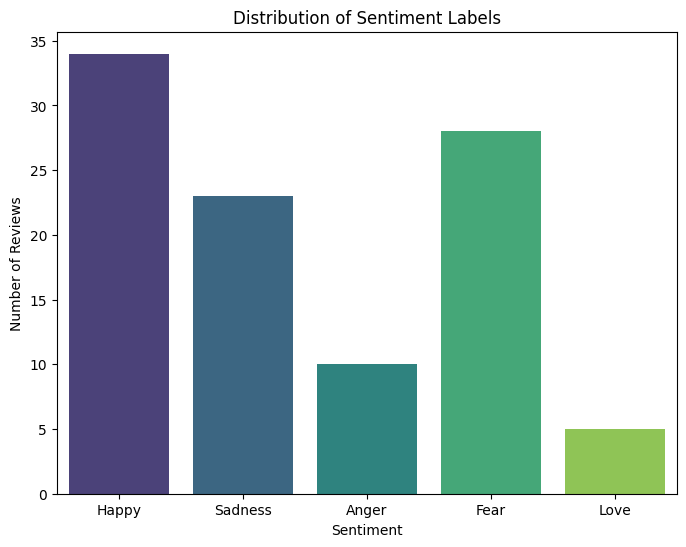

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment_label', data=df, hue='sentiment_label', palette='viridis', legend=False)
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()